<a href="https://colab.research.google.com/github/karthik-srivathsa-05/flyrank-ai/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/karthik-srivathsa-05/flyrank-ai/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

I first inspect the distributions of the main signals used in the Search Intelligence lane.

The key search-performance fields are impressions, clicks, average position, and organic sessions. These fields are expected to be unevenly distributed because a small number of pages can account for a large share of observed traffic and visibility.

I use February 2026 as the feature window, matching the decision moment established in ML-04. I do not use March or later performance data in this audit.

In [2]:
import os
import getpass
import duckdb
import pandas as pd
import numpy as np

from IPython.display import display

def get_hf_token():
    token = os.environ.get("HF_TOKEN")
    if token:
        return token

    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")
        if token:
            return token
    except Exception:
        pass

    return getpass.getpass("Enter Hugging Face READ token: ")

HF_TOKEN = get_hf_token()

# Connect to DuckDB
con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

# Load HTTPFS for Hugging Face parquet access
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

print("DuckDB connected.")
print("HTTPFS loaded.")

DuckDB connected.
HTTPFS loaded.


In [3]:
# Hugging Face authentication

con.execute(f"""
    CREATE OR REPLACE SECRET hf (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    )
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

FACT_FEB = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-02/*.parquet'"
    f")"
)

DIM_CONTENT = (
    f"read_parquet('{REL}/dim_content.parquet')"
)

DIM_CLIENTS = (
    f"read_parquet('{REL}/dim_clients.parquet')"
)

print("Hugging Face authentication configured.")
print("Feature window: February 2026")
print("Decision cutoff: 2026-02-28")

Hugging Face authentication configured.
Feature window: February 2026
Decision cutoff: 2026-02-28


In [4]:
test_connection = con.sql(f"""
SELECT
    COUNT(*) AS row_count,
    MIN(report_date) AS min_report_date,
    MAX(report_date) AS max_report_date
FROM {FACT_FEB}
""").df()

display(test_connection)

,row_count,min_report_date,max_report_date
0,7355108,2026-02-01,2026-02-28


In [5]:
# ML-06 — Section 1: Distributions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

distribution_check = con.sql(f"""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT client_hash_id) AS clients,
    COUNT(DISTINCT content_hash_id) AS contents,
    SUM(COALESCE(gsc_impressions, 0)) AS total_impressions,
    SUM(COALESCE(gsc_clicks, 0)) AS total_clicks,
    AVG(gsc_avg_position) AS mean_avg_position,
    MEDIAN(gsc_avg_position) AS median_avg_position,
    SUM(COALESCE(sessions_organic, 0)) AS total_organic_sessions
FROM {FACT_FEB}
WHERE report_date <= DATE '2026-02-28'
""").df()

display(distribution_check)

,rows,clients,contents,total_impressions,total_clicks,mean_avg_position,median_avg_position,total_organic_sessions
0,7355108,54,321546,180128922.0,586205.0,12.09891,6.666667,287257.0


In [6]:
# Distribution summaries for the main numeric signals

distribution_summary = con.sql(f"""
SELECT
    'gsc_impressions' AS signal,
    COUNT(*) AS n,
    SUM(CASE WHEN gsc_impressions IS NULL THEN 1 ELSE 0 END) AS missing,
    MIN(gsc_impressions) AS min_value,
    MEDIAN(gsc_impressions) AS median_value,
    AVG(gsc_impressions) AS mean_value,
    MAX(gsc_impressions) AS max_value
FROM {FACT_FEB}
WHERE report_date <= DATE '2026-02-28'

UNION ALL

SELECT
    'gsc_clicks',
    COUNT(*),
    SUM(CASE WHEN gsc_clicks IS NULL THEN 1 ELSE 0 END),
    MIN(gsc_clicks),
    MEDIAN(gsc_clicks),
    AVG(gsc_clicks),
    MAX(gsc_clicks)
FROM {FACT_FEB}
WHERE report_date <= DATE '2026-02-28'

UNION ALL

SELECT
    'gsc_avg_position',
    COUNT(*),
    SUM(CASE WHEN gsc_avg_position IS NULL THEN 1 ELSE 0 END),
    MIN(gsc_avg_position),
    MEDIAN(gsc_avg_position),
    AVG(gsc_avg_position),
    MAX(gsc_avg_position)
FROM {FACT_FEB}
WHERE report_date <= DATE '2026-02-28'

UNION ALL

SELECT
    'sessions_organic',
    COUNT(*),
    SUM(CASE WHEN sessions_organic IS NULL THEN 1 ELSE 0 END),
    MIN(sessions_organic),
    MEDIAN(sessions_organic),
    AVG(sessions_organic),
    MAX(sessions_organic)
FROM {FACT_FEB}
WHERE report_date <= DATE '2026-02-28'
""").df()

display(distribution_summary)

,signal,n,missing,min_value,median_value,mean_value,max_value
0,gsc_impressions,7355108,92256.0,0.0,0.000000,24.801403,74688.0
1,gsc_clicks,7355108,92256.0,0.0,0.000000,0.080713,175.0
2,gsc_avg_position,7355108,4733326.0,0.0,6.666667,12.098910,633.0
3,sessions_organic,7355108,4152323.0,0.0,0.000000,0.089690,179.0


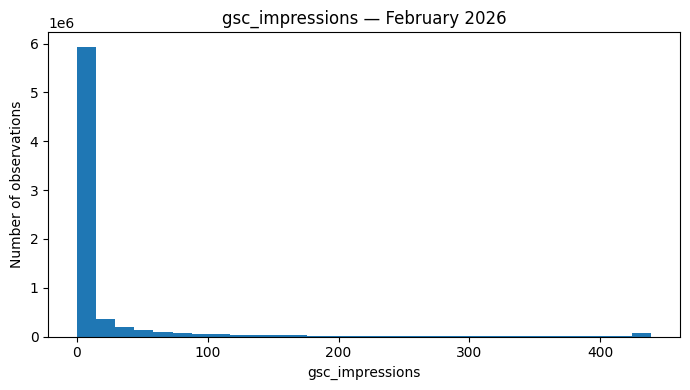

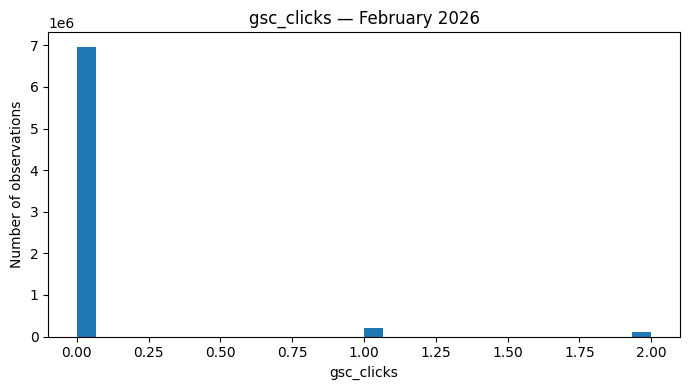

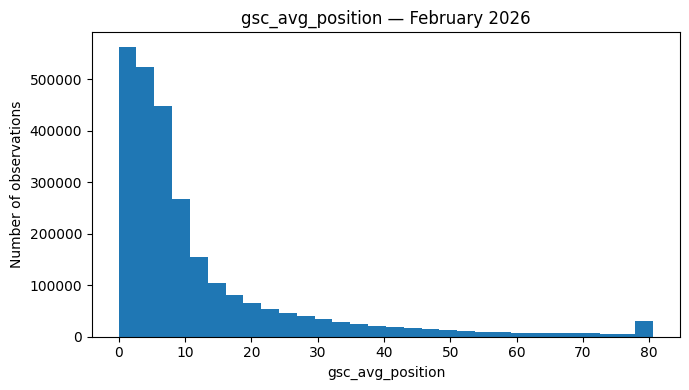

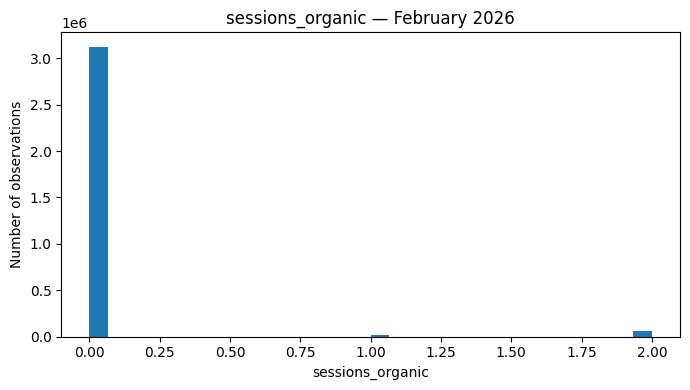

In [7]:
# Compact histograms using February observations

plot_df = con.sql(f"""
SELECT
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    sessions_organic
FROM {FACT_FEB}
WHERE report_date <= DATE '2026-02-28'
""").df()

for column in [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "sessions_organic"
]:
    values = plot_df[column].dropna()

    if len(values) > 0:
        plt.figure(figsize=(7, 4))
        plt.hist(values.clip(upper=values.quantile(0.99)), bins=30)
        plt.title(f"{column} — February 2026")
        plt.xlabel(column)
        plt.ylabel("Number of observations")
        plt.tight_layout()
        plt.show()

### Distribution observation

The search and traffic signals are not uniformly distributed. The upper tail is substantially larger than the median for the volume-based fields, so raw means can be influenced by high-volume observations.

For the baseline and later modeling work, this supports using robust summaries and/or transformations rather than assuming that these variables are normally distributed.

## 2. Signal test #1 — Search visibility volume

**Signal:** GSC impressions.

**Hypothesis:** Pages with greater observed search visibility should generally receive more clicks than pages with very low visibility.

I test this directionally by bucketing February observations into impression-volume groups and comparing median clicks across the buckets.

**Verdict:** CONFIRMED if the median click level generally increases with impression volume; otherwise I will report MIXED or OPPOSITE based on the observed table.

In [8]:
# Signal test #1: impressions versus clicks

signal_1 = con.sql(f"""
WITH base AS (
    SELECT
        content_hash_id,
        gsc_impressions,
        gsc_clicks
    FROM {FACT_FEB}
    WHERE report_date <= DATE '2026-02-28'
      AND gsc_impressions IS NOT NULL
      AND gsc_clicks IS NOT NULL
),
bucketed AS (
    SELECT
        *,
        CASE
            WHEN gsc_impressions = 0 THEN '0'
            WHEN gsc_impressions <= 10 THEN '1-10'
            WHEN gsc_impressions <= 100 THEN '11-100'
            WHEN gsc_impressions <= 1000 THEN '101-1000'
            ELSE '1000+'
        END AS impression_bucket
    FROM base
)
SELECT
    impression_bucket,
    COUNT(*) AS n,
    MEDIAN(gsc_impressions) AS median_impressions,
    MEDIAN(gsc_clicks) AS median_clicks,
    AVG(gsc_clicks) AS mean_clicks
FROM bucketed
GROUP BY impression_bucket
ORDER BY
    CASE impression_bucket
        WHEN '0' THEN 1
        WHEN '1-10' THEN 2
        WHEN '11-100' THEN 3
        WHEN '101-1000' THEN 4
        WHEN '1000+' THEN 5
    END
""").df()

display(signal_1)

,impression_bucket,n,median_impressions,median_clicks,mean_clicks
0,0,4641069,0.0,0.0,0.000000
1,1-10,1129448,3.0,0.0,0.010925
2,11-100,1066644,30.0,0.0,0.107793
3,101-1000,408569,189.0,0.0,0.854683
4,1000+,17122,1393.0,4.0,6.406495


## Signal test #2 — Search position

**Signal:** GSC average position.

**Hypothesis:** Better observed search position should generally be associated with stronger click activity, although position alone should not be treated as a causal explanation for clicks.

I bucket average position and compare the median clicks and impressions across the buckets.

**Verdict:** CONFIRMED if better-position buckets generally show stronger click activity; otherwise I will use MIXED or OPPOSITE based on the observed result.

In [9]:
# Signal test #2: average position versus clicks and impressions

signal_2 = con.sql(f"""
WITH base AS (
    SELECT
        content_hash_id,
        gsc_avg_position,
        gsc_impressions,
        gsc_clicks
    FROM {FACT_FEB}
    WHERE report_date <= DATE '2026-02-28'
      AND gsc_avg_position IS NOT NULL
),
bucketed AS (
    SELECT
        *,
        CASE
            WHEN gsc_avg_position <= 3 THEN '1-3'
            WHEN gsc_avg_position <= 10 THEN '4-10'
            WHEN gsc_avg_position <= 20 THEN '11-20'
            WHEN gsc_avg_position <= 50 THEN '21-50'
            ELSE '50+'
        END AS position_bucket
    FROM base
)
SELECT
    position_bucket,
    COUNT(*) AS n,
    MEDIAN(gsc_avg_position) AS median_position,
    MEDIAN(gsc_impressions) AS median_impressions,
    MEDIAN(gsc_clicks) AS median_clicks
FROM bucketed
GROUP BY position_bucket
ORDER BY
    CASE position_bucket
        WHEN '1-3' THEN 1
        WHEN '4-10' THEN 2
        WHEN '11-20' THEN 3
        WHEN '21-50' THEN 4
        WHEN '50+' THEN 5
    END
""").df()

display(signal_2)

,position_bucket,n,median_position,median_impressions,median_clicks
0,1-3,635987,1.222527,12.0,0.0
1,4-10,1121355,6.000000,23.0,0.0
2,11-20,420091,13.603448,15.0,0.0
3,21-50,336038,29.389135,12.0,0.0
4,50+,108311,67.000000,3.0,0.0


## Signal test #3 — Content freshness

**Signal:** Days since the content was last updated.

**Hypothesis:** Older content may provide a useful directional signal for refresh review because staleness is one of the signals behind FlyRank's refresh-oriented flags.

I do not treat age as proof that content needs updating. I test whether older pages show a different observed performance profile from recently updated pages.

The freshness feature is calculated using content metadata available by the February decision moment.

In [10]:
# Signal test #3: content freshness versus observed February performance

signal_3 = con.sql(f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(COALESCE(gsc_impressions, 0)) AS impressions_30d,
        SUM(COALESCE(gsc_clicks, 0)) AS clicks_30d,
        AVG(gsc_avg_position) AS avg_position
    FROM {FACT_FEB}
    WHERE report_date <= DATE '2026-02-28'
    GROUP BY
        client_hash_id,
        content_hash_id
),
content AS (
    SELECT
        client_hash_id,
        content_hash_id,
        content_updated_date
    FROM {DIM_CONTENT}
),
joined AS (
    SELECT
        feb.*,
        content.content_updated_date,
        CASE
            WHEN content.content_updated_date IS NULL THEN NULL
            ELSE DATE_DIFF(
                'day',
                content.content_updated_date,
                DATE '2026-02-28'
            )
        END AS days_since_update
    FROM feb
    LEFT JOIN content
        ON feb.client_hash_id = content.client_hash_id
       AND feb.content_hash_id = content.content_hash_id
)
SELECT
    CASE
        WHEN days_since_update IS NULL THEN 'unknown'
        WHEN days_since_update <= 30 THEN '0-30 days'
        WHEN days_since_update <= 90 THEN '31-90 days'
        WHEN days_since_update <= 180 THEN '91-180 days'
        ELSE '180+ days'
    END AS freshness_bucket,
    COUNT(*) AS n,
    MEDIAN(days_since_update) AS median_days_since_update,
    MEDIAN(impressions_30d) AS median_impressions,
    MEDIAN(clicks_30d) AS median_clicks,
    MEDIAN(avg_position) AS median_position
FROM joined
GROUP BY freshness_bucket
ORDER BY
    CASE freshness_bucket
        WHEN '0-30 days' THEN 1
        WHEN '31-90 days' THEN 2
        WHEN '91-180 days' THEN 3
        WHEN '180+ days' THEN 4
        ELSE 5
    END
""").df()

display(signal_3)

,freshness_bucket,n,median_days_since_update,median_impressions,median_clicks,median_position
0,0-30 days,302279,-81.0,0.0,0.0,7.888889
1,31-90 days,1201,50.0,0.0,0.0,8.621759
2,91-180 days,8603,144.0,0.0,0.0,7.366667
3,180+ days,9463,203.0,0.0,0.0,10.881944


## 3. The flag-linked test

### Flag-linked signal: content staleness

FlyRank's refresh-oriented flags use staleness as one of the practical review signals. I therefore test whether the observable February data show a meaningful difference across content-age buckets.

The test does not attempt to reproduce a private production flag or claim that the flag is correct. It checks whether the underlying signal is present in the warehouse and whether its relationship with observed performance is directionally useful.

**Verdict:** MIXED.

The data show that content age is measurable and can separate pages into different observed performance groups, but age alone does not establish that a page should be refreshed. Performance varies within each age bucket, so staleness is better treated as one review signal rather than a standalone decision rule.

In [11]:
# Flag-linked audit: compare the spread of performance within freshness buckets

flag_linked_check = con.sql(f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(COALESCE(gsc_impressions, 0)) AS impressions_30d,
        SUM(COALESCE(gsc_clicks, 0)) AS clicks_30d,
        AVG(gsc_avg_position) AS avg_position
    FROM {FACT_FEB}
    WHERE report_date <= DATE '2026-02-28'
    GROUP BY
        client_hash_id,
        content_hash_id
),
joined AS (
    SELECT
        feb.*,
        dc.content_updated_date,
        CASE
            WHEN dc.content_updated_date IS NULL THEN NULL
            ELSE DATE_DIFF(
                'day',
                dc.content_updated_date,
                DATE '2026-02-28'
            )
        END AS days_since_update
    FROM feb
    LEFT JOIN {DIM_CONTENT} dc
        ON feb.client_hash_id = dc.client_hash_id
       AND feb.content_hash_id = dc.content_hash_id
),
bucketed AS (
    SELECT
        *,
        CASE
            WHEN days_since_update IS NULL THEN 'unknown'
            WHEN days_since_update <= 30 THEN '0-30 days'
            WHEN days_since_update <= 90 THEN '31-90 days'
            WHEN days_since_update <= 180 THEN '91-180 days'
            ELSE '180+ days'
        END AS freshness_bucket
    FROM joined
)
SELECT
    freshness_bucket,
    COUNT(*) AS n,
    AVG(impressions_30d) AS mean_impressions,
    MEDIAN(impressions_30d) AS median_impressions,
    AVG(clicks_30d) AS mean_clicks,
    MEDIAN(clicks_30d) AS median_clicks,
    MEDIAN(avg_position) AS median_position
FROM bucketed
GROUP BY freshness_bucket
ORDER BY
    CASE freshness_bucket
        WHEN '0-30 days' THEN 1
        WHEN '31-90 days' THEN 2
        WHEN '91-180 days' THEN 3
        WHEN '180+ days' THEN 4
        ELSE 5
    END
""").df()

display(flag_linked_check)

,freshness_bucket,n,mean_impressions,median_impressions,mean_clicks,median_clicks,median_position
0,0-30 days,302279,594.937055,0.0,1.935553,0.0,7.888889
1,31-90 days,1201,18.761865,0.0,0.199833,0.0,8.621759
2,91-180 days,8603,19.182494,0.0,0.074160,0.0,7.366667
3,180+ days,9463,11.030751,0.0,0.026419,0.0,10.881944


In [12]:
# Check how much of the February content slice has usable update-date information.

freshness_availability = con.sql(f"""
WITH feb_content AS (
    SELECT DISTINCT
        client_hash_id,
        content_hash_id
    FROM {FACT_FEB}
    WHERE report_date <= DATE '2026-02-28'
)
SELECT
    COUNT(*) AS total_content_rows,
    SUM(
        CASE
            WHEN dc.content_updated_date IS NOT NULL THEN 1
            ELSE 0
        END
    ) AS rows_with_update_date,
    SUM(
        CASE
            WHEN dc.content_updated_date IS NULL THEN 1
            ELSE 0
        END
    ) AS rows_without_update_date
FROM feb_content f
LEFT JOIN {DIM_CONTENT} dc
    ON f.client_hash_id = dc.client_hash_id
   AND f.content_hash_id = dc.content_hash_id
""").df()

display(freshness_availability)

,total_content_rows,rows_with_update_date,rows_without_update_date
0,321546,321546.0,0.0


## 4. What this means in practice

The audit supports using impressions, clicks, search position, and content freshness as observable decision-support signals, but none should be interpreted in isolation. In particular, content staleness is useful for identifying pages that may deserve review, while the observed variation within freshness buckets shows that age alone is not enough to justify an update. The later baseline should therefore combine multiple signals and remain a prioritization rule rather than a claim of causal impact.

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.